In [1]:
import torch
import numpy as np
import random
import os
import pandas as pd
import seaborn as sns
import torch.optim as optim
import matplotlib.pyplot as plt
from pyepo.func import SPOPlus
import math

# Set seed function generated by Google Gemini
def set_seeds(seed=42):
    """
    Sets random seeds for Python, NumPy, and PyTorch to ensure 
    reproducible results.
    """
    # 1. Set the Python built-in random module seed
    random.seed(seed)
    
    # 2. Set the NumPy seed
    np.random.seed(seed)
    
    # 3. Set the PyTorch seeds
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # If using multi-GPU
    
    # 4. Ensure deterministic behavior in CuDNN (if using GPU)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # 5. Set environment variable for hash seed
    os.environ['PYTHONHASHSEED'] = str(seed)

    print(f"Random seeds set to {seed}")

# Run
set_seeds(42)

Random seeds set to 42


In [2]:
dfV = pd.read_csv("HELMET_Triangular_Targets.csv")
dfV

,ptid_idx,hour,true_scans,interpolated_mls_class,last_known_mls_class,proba_0,proba_1,proba_2,proba_3,ipw,kld,proxy_reward
0,1,0,0,0,NaN,0.445908,0.318474,0.118668,0.116950,1.000000,0.000000,0.0
1,1,1,1,0,0.0,0.455688,0.282771,0.137140,0.124401,1.000000,0.003788,0.0
2,1,2,0,0,0.0,0.455688,0.282771,0.137140,0.124401,1.034962,0.000000,0.0
3,1,3,0,0,0.0,0.455688,0.282771,0.137140,0.124401,1.034365,0.000000,0.0
4,1,4,0,0,0.0,0.455688,0.282771,0.137140,0.124401,1.033779,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
138476,674,332,0,1,1.0,0.144472,0.489204,0.258802,0.107521,1.000063,0.000028,0.0
138477,674,333,0,1,1.0,0.144472,0.489204,0.258802,0.107521,1.000067,0.000000,0.0
138478,674,334,0,1,1.0,0.143071,0.479518,0.274290,0.103121,1.000045,0.000649,0.0
138479,674,335,0,1,1.0,0.143071,0.479518,0.274290,0.103121,1.000065,0.000000,0.0


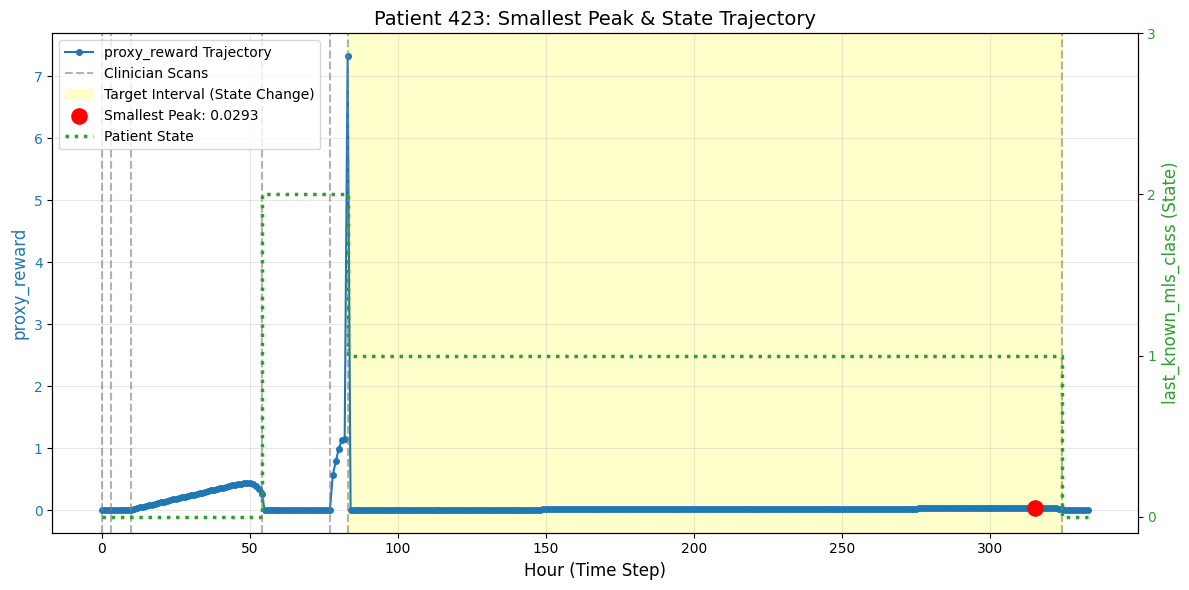

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  # Corrected import

# visualize function generated by Google Gemini
def visualize_smallest_peak_interval(df, value_col='proxy_reward', state_col='last_known_mls_class'):
    """
    Finds the smallest peak in a state-change interval and plots the patient's timeline,
    including a secondary axis for the last known state.
    """
    min_peak = {
        'ptid': None,
        'start_hour': None,
        'end_hour': None,
        'peak_hour': None,
        'peak_value': float('inf')
    }
    
    df_sorted = df.sort_values(by=['ptid_idx', 'hour']).reset_index(drop=True)
    
    # --- SEARCH PHASE ---
    for ptid, group in df_sorted.groupby('ptid_idx'):
        scan_ilocs = np.where(group['true_scans'] == 1)[0]
        
        if len(scan_ilocs) < 2:
            continue 
            
        for i in range(len(scan_ilocs) - 1):
            start_iloc = scan_ilocs[i]
            end_iloc = scan_ilocs[i+1]
            
            state_start = group.iloc[start_iloc][state_col]
            state_end = group.iloc[end_iloc][state_col]
            
            # Filter for state change
            if pd.notna(state_start) and pd.notna(state_end) and state_start != state_end:
                interval_data = group.iloc[start_iloc + 1 : end_iloc]
                
                if not interval_data.empty:
                    interval_peak_val = interval_data[value_col].max()
                    
                    if interval_peak_val < min_peak['peak_value']:
                        min_peak['peak_value'] = interval_peak_val
                        min_peak['ptid'] = ptid
                        min_peak['start_hour'] = group.iloc[start_iloc]['hour']
                        min_peak['end_hour'] = group.iloc[end_iloc]['hour']
                        
                        peak_row = interval_data[interval_data[value_col] == interval_peak_val].iloc[0]
                        min_peak['peak_hour'] = peak_row['hour']

    if min_peak['ptid'] is None:
        raise ValueError("No valid state-change intervals found.")

    # --- PLOTTING PHASE ---
    patient_data = df_sorted[df_sorted['ptid_idx'] == min_peak['ptid']]
    
    # Correct way to create subplots
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Primary Axis (Left) - Proxy Reward
    ax1.set_xlabel("Hour (Time Step)", fontsize=12)
    ax1.set_ylabel(value_col, fontsize=12, color='#1f77b4')
    ax1.plot(patient_data['hour'], patient_data[value_col], 
             label=f'{value_col} Trajectory', color='#1f77b4', marker='o', markersize=4)
    ax1.tick_params(axis='y', labelcolor='#1f77b4')
    
    # Mark Clinician Scans
    scan_hours = patient_data[patient_data['true_scans'] == 1]['hour']
    for sh in scan_hours:
        label = 'Clinician Scans' if sh == scan_hours.iloc[0] else ""
        ax1.axvline(x=sh, color='gray', linestyle='--', alpha=0.6, label=label)
        
    # Highlight Target Interval
    ax1.axvspan(min_peak['start_hour'], min_peak['end_hour'], 
                color='yellow', alpha=0.2, label='Target Interval (State Change)')
    
    # Highlight Smallest Peak
    ax1.scatter([min_peak['peak_hour']], [min_peak['peak_value']], 
                color='red', s=120, zorder=5, label=f"Smallest Peak: {min_peak['peak_value']:.4f}")
    
    # Secondary Axis (Right) - Last Known State
    ax2 = ax1.twinx()
    ax2.set_ylabel(f'{state_col} (State)', fontsize=12, color='#2ca02c')
    ax2.step(patient_data['hour'], patient_data[state_col], 
             label='Patient State', color='#2ca02c', linestyle=':', linewidth=2.5, where='post')
    ax2.tick_params(axis='y', labelcolor='#2ca02c')
    
    # Integer formatting for classes
    state_min = patient_data[state_col].min(skipna=True)
    state_max = patient_data[state_col].max(skipna=True)
    if pd.notna(state_min) and pd.notna(state_max):
        ax2.set_yticks(np.arange(int(state_min), int(state_max) + 2))
    
    # Combined Legend
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
    
    plt.title(f"Patient {min_peak['ptid']}: Smallest Peak & State Trajectory", fontsize=14)
    ax1.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

# --- Run the visualization ---
visualize_smallest_peak_interval(dfV)